In [120]:
# Analysis on Walmart Dataset

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings


In [154]:
df_wal=pd.read_csv('Walmart.csv')
df_wal.tail(5)
warnings.filterwarnings("ignore")

In [13]:
df_wal.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [121]:
df_wal.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019


-------------------------------------
### 1. How Holidays impact weekly sales 
-------------------------------------

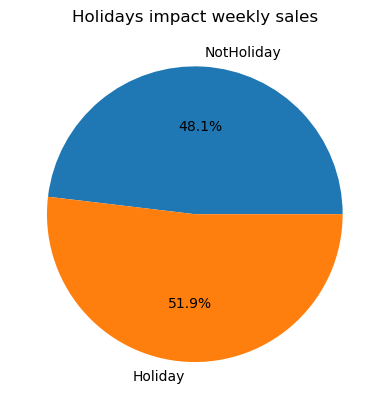

In [133]:
# how holidays impact weekly sales 

''' # Rename using Index
week_pie = df_wal.groupby('Holiday_Flag')['Weekly_Sales'].mean()
# rename with index
label= ['NotHoliday' if idx==0 else 'Holiday' for idx in week_pie.index] '''

# rename as a dictionary
week_pie = df_wal.groupby('Holiday_Flag')['Weekly_Sales'].mean().rename({0:'NotHoliday', 1:'Holiday'})

plt.title("Holidays impact weekly sales")
plt.pie(week_pie, labels=label , autopct="%.1f%%")
plt.show()

#### Analysis : The PIE chart shows holidays doesnt affect the overall sales

----------------------------------
### 2. Weekly sales for store 33
-------------------------------------

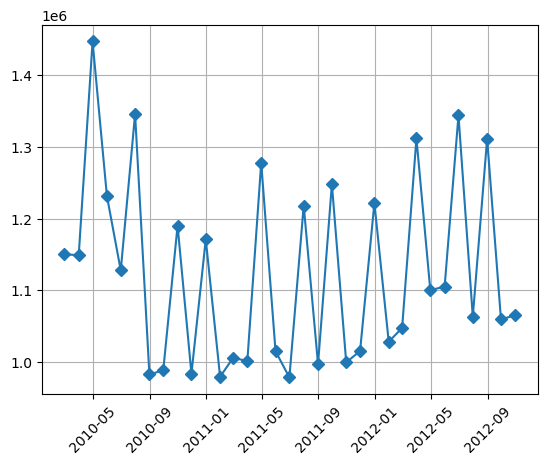

Date            2010-04-30 00:00:00
Weekly_Sales             1446761.46
Name: 2, dtype: object


In [124]:
# weekly sales for one store
df_week_sale_33 = df_wal[df_wal['Store']==33][['Date','Weekly_Sales']]

#Simple plot
#plt.plot(df_week_sale_33['Date'], df_week_sale_33['Weekly_Sales'])

# monthly sales for one store
# change to datetime format
df_week_sale_33['Date'] = pd.to_datetime(df_week_sale_33['Date'], format='%d-%m-%Y')

df_month_sale_33 = df_week_sale_33.resample('ME', on='Date')['Weekly_Sales'].sum().reset_index()

# plot the monthly sales
plt.plot(df_month_sale_33['Date'],df_month_sale_33['Weekly_Sales'], marker ='D')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# month with highest sales
month_high_sales=df_month_sale_33.loc[df_month_sale_33['Weekly_Sales'].idxmax()]
print(month_high_sales)

----------------------------------
### 3. Plot total company sales by year
----------------------------------

In [130]:
# change to datetime format
df_wal['Date'] = pd.to_datetime(df_wal['Date'],dayfirst=True)

# Add Year column
df_wal['Year'] = df_wal['Date'].dt.year

# Total yearly sales for each store
yearly_sales = df_wal.groupby(['Store', 'Year'])['Weekly_Sales'].sum().reset_index()
# Weekly_Sales column is actually the yearly total now since we summed all weeks.
#print(yearly_sales.head(10))
yearly_sales.pivot(index='Year', columns='Store', values='Weekly_Sales')

Store,1,2,3,4,5,6,7,8,9,10,...,36,37,38,39,40,41,42,43,44,45
Year,,,,,,,,,,,,,,,,,,,,,
2010,73278832.00,95277864.19,18745419.00,9.568047e+07,14836030.77,76912320.69,25568078.15,43204474.84,25129219.76,94472202.21,...,21153125.69,24508469.86,16587794.52,65782276.32,46357359.52,57738220.65,25498089.91,31537005.99,13607519.45,38536343.37
2011,80921918.83,98607881.42,20816876.57,1.110923e+08,16470820.00,80528762.95,30662640.52,47512786.16,28685969.65,98916894.74,...,18972618.75,27081495.77,19940758.45,75777603.30,50340542.93,66715874.31,29117302.67,32053195.45,15498194.67,41135367.88
2012,68202058.02,81496695.37,18024439.50,9.277119e+07,14168838.13,66315047.00,25367556.47,39233920.13,23974029.58,78228616.94,...,13286470.53,22612774.69,18631073.45,65885662.85,41172407.34,56887839.93,24950359.85,26975233.97,14187373.72,32723630.17


Text(0, 0.5, 'Sales $')

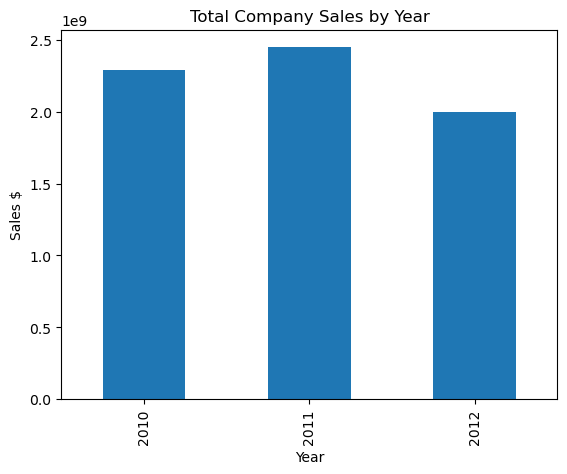

In [131]:
# Plot total company sales by year:
yearly_sales.groupby('Year')['Weekly_Sales'].sum().plot(kind='bar')
plt.title('Total Company Sales by Year')
plt.ylabel('Sales $')

In [137]:
df_wal.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012
6434,45,2012-10-26,760281.43,0,58.85,3.882,192.308899,8.667,2012


--------------------------------------------------------------------
### 4.a. Correlation with factors affecting Sales
--------------------------------------------------------------------

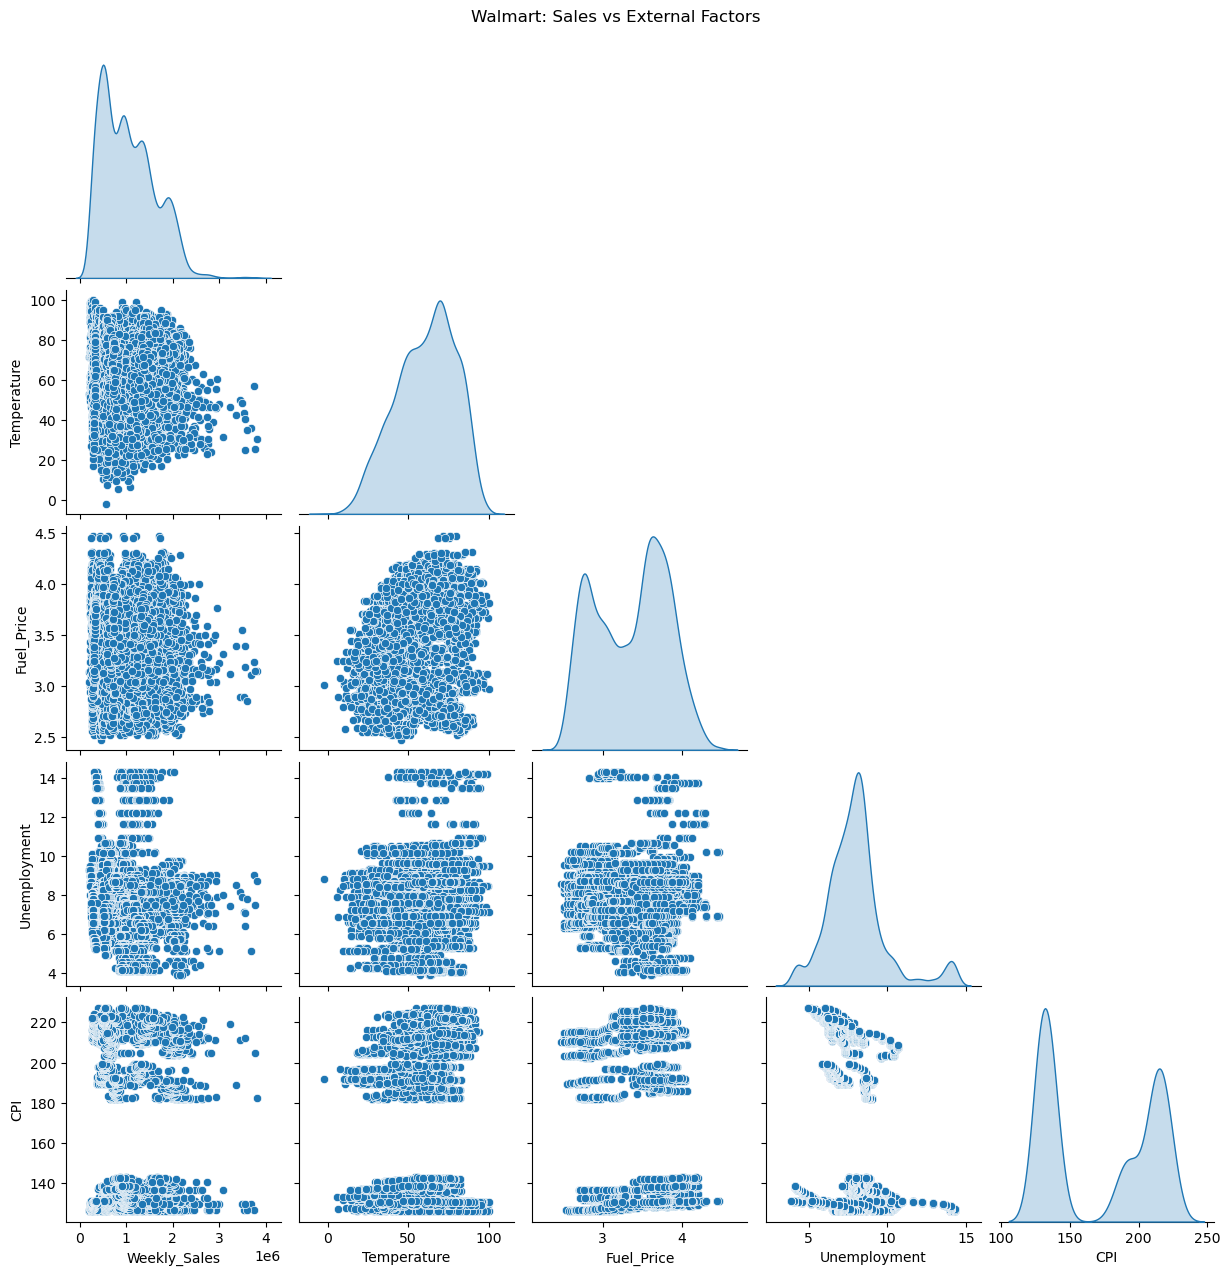

In [161]:
#handle inf globally
pd.option_context('mode.use_inf_as_na', True) 
# Pairplot 
cols = ['Weekly_Sales','Temperature','Fuel_Price','Unemployment','CPI']
df_wal[cols].sample(5000).dropna()
#plotting the Pairplot: added KDE on diagonal, so no duplicate plots
sns.pairplot(df_wal[cols], diag_kind='kde', corner=True)
# adding super title
plt.suptitle('Walmart: Sales vs External Factors', y=1.02)
plt.show()

### 4.b. Lets add Holiday to HUE to see how it affecting Sales


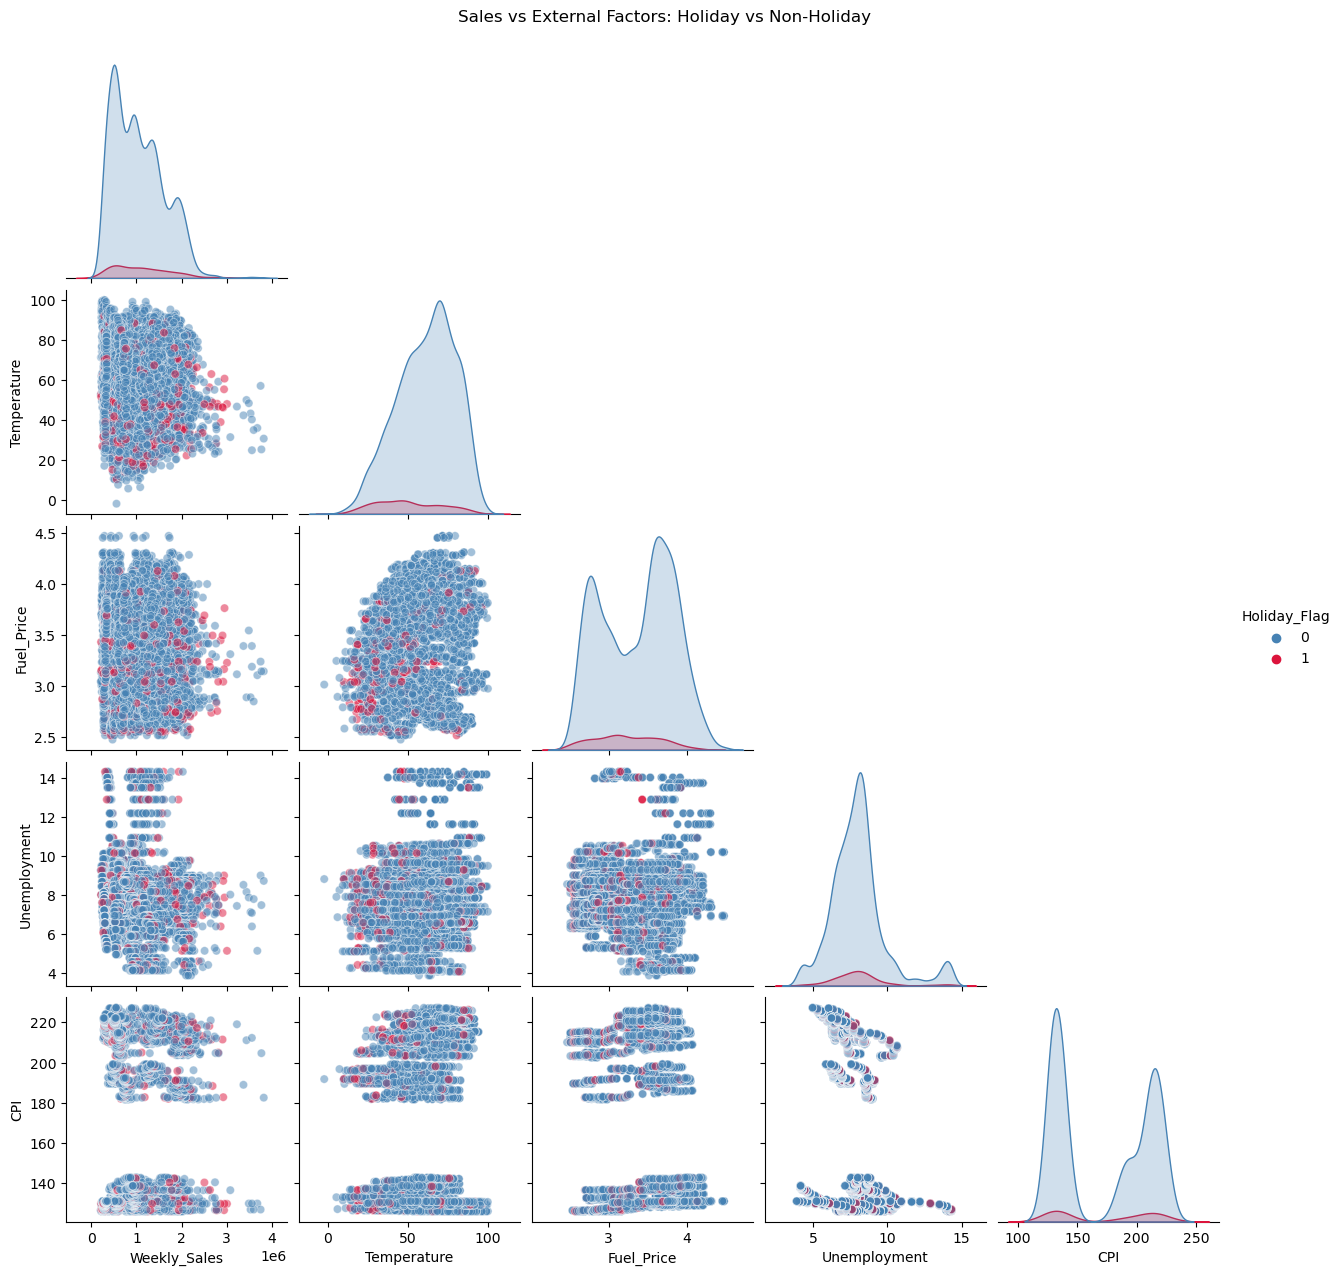

In [168]:
cols = ['Weekly_Sales','Temperature','Fuel_Price','Unemployment','CPI','Holiday_Flag']
# sampling the data 
df_wal[cols].sample(5000).dropna()
# Drop NaNs and make sure Holiday_Flag is int/category for clean legend
df_plot = df_wal.dropna().copy()
df_plot['Holiday_Flag'] = df_plot['Holiday_Flag'].astype('category')

sns.pairplot(
    df_plot, 
    vars=['Weekly_Sales','Temperature','Fuel_Price','Unemployment','CPI'],
    hue='Holiday_Flag',
    palette={0:'steelblue', 1:'crimson'},
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha':0.5} # make points see-through since there's overlap
)

plt.suptitle('Sales vs External Factors: Holiday vs Non-Holiday', y=1.02)
plt.show()

#### Analysis:
1. Weekly_Sales vs Unemployment: shows higher unemployment during high sales and during holidays unemployment is less.
2. Weekly_Sales vs Temperature: More sales during Temperature change.
3. Fuel_Price vs CPI: Macro factors positively correlated    

--------------------------------------------------------------------
### 5. Best Month Sales: Is Season affecting Sales
--------------------------------------------------------------------

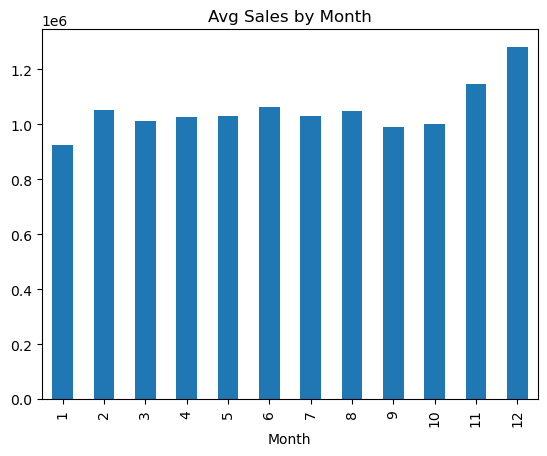

In [166]:
# change to datetime format
df_wal['Date'] = pd.to_datetime(df_wal['Date'],dayfirst=True)
df_wal['Month'] = df_wal['Date'].dt.month
monthly_avg = df_wal.groupby('Month')['Weekly_Sales'].mean()
monthly_avg.plot(kind='bar', title='Avg Sales by Month')
plt.show()

# Flag outlier weeks > 3 std devs
mean, std = df_wal['Weekly_Sales'].mean(), df_wal['Weekly_Sales'].std()
outliers = df_wal[df_wal['Weekly_Sales'] > mean + 3*std]

#### Yes Year end Sales are high

--------------------------------------------------------------------
### 6. Which stores have Less sales at End Of Year
--------------------------------------------------------------------

In [172]:
yearly = df_wal.groupby(['Store', df_wal['Date'].dt.year])['Weekly_Sales'].sum().unstack()
yearly['Growth_11_12'] = (yearly[2012] - yearly[2011]) / yearly[2011] * 100
yearly.sort_values('Growth_11_12').head(10) # worst 10

Date,2010,2011,2012,Growth_11_12
Store,,,,
36,2.115313e+07,1.897262e+07,13286470.53,-29.970287
14,1.054622e+08,1.060963e+08,77441398.26,-27.008369
21,3.763111e+07,4.023488e+07,30251886.71,-24.811796
15,3.202353e+07,3.228262e+07,24827530.71,-23.093209
27,9.001318e+07,9.192268e+07,71920056.12,-21.760274
10,9.447220e+07,9.891689e+07,78228616.94,-20.914807
19,7.258053e+07,7.484190e+07,59212433.28,-20.883311
45,3.853634e+07,4.113537e+07,32723630.17,-20.448918
29,2.694683e+07,2.795035e+07,22244381.62,-20.414644


--------------------------------------------------------------------
### 7. Do extreme Temperature help Sales
--------------------------------------------------------------------

<Axes: xlabel='Temp_Bin'>

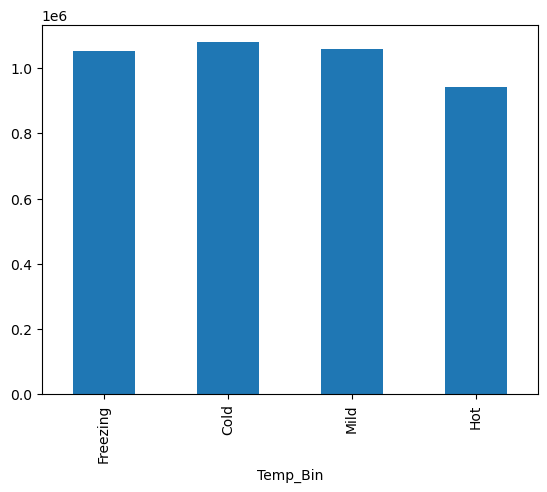

In [173]:
df_wal['Temp_Bin'] = pd.cut(df_wal['Temperature'], bins=[0,32,60,80,120], labels=['Freezing','Cold','Mild','Hot'])
df_wal.groupby('Temp_Bin')['Weekly_Sales'].mean().plot(kind='bar')

#### ACs in heat waves, heaters in cold snaps = sales spikes.

--------------------------------------------------------------------
### 8.Recession indicator impact
--------------------------------------------------------------------

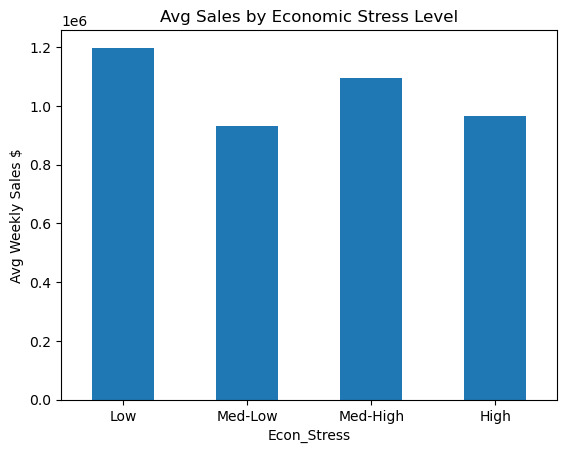

In [177]:
df_wal['Econ_Stress'] = df_wal['CPI'] * df_wal['Unemployment']
stress_bins = pd.qcut(df_wal['Econ_Stress'], 4, labels=['Low','Med-Low','Med-High','High'])

df_wal.groupby(stress_bins)['Weekly_Sales'].mean().plot(
    kind='bar', 
    title='Avg Sales by Economic Stress Level'
)
plt.ylabel('Avg Weekly Sales $')
plt.xticks(rotation=0)
plt.show()

#### Analysis: Best sales happen when CPI & Unemployment is lowest. Walmart sales hold up pretty well under stress

--------------------------------------------------------------------
### 9. What’s the true week-of-year effect?
--------------------------------------------------------------------

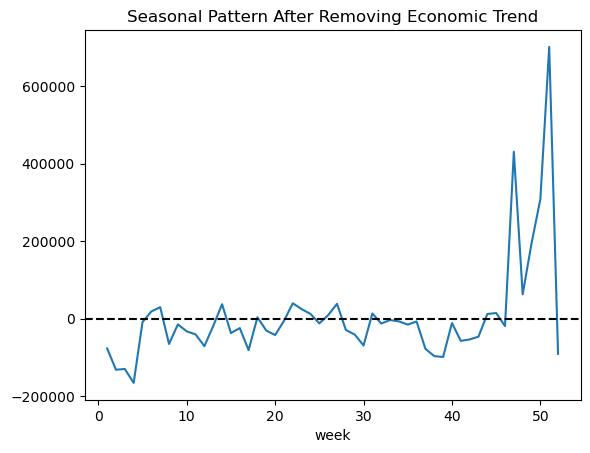

In [178]:
# Remove economic trend first
df_wal['Sales_Detrended'] = df_wal['Weekly_Sales'] - df_wal['Weekly_Sales'].rolling(52).mean()

df_wal.groupby(df_wal['Date'].dt.isocalendar().week)['Sales_Detrended'].mean().plot()
plt.title('Seasonal Pattern After Removing Economic Trend')
plt.axhline(0, color='k', linestyle='--')

#### There is spike from Week 48. It shows holidays affect Sales.

--------------------------------------------------------------------
### Walmart Dataset Analysis Dashboard
--------------------------------------------------------------------

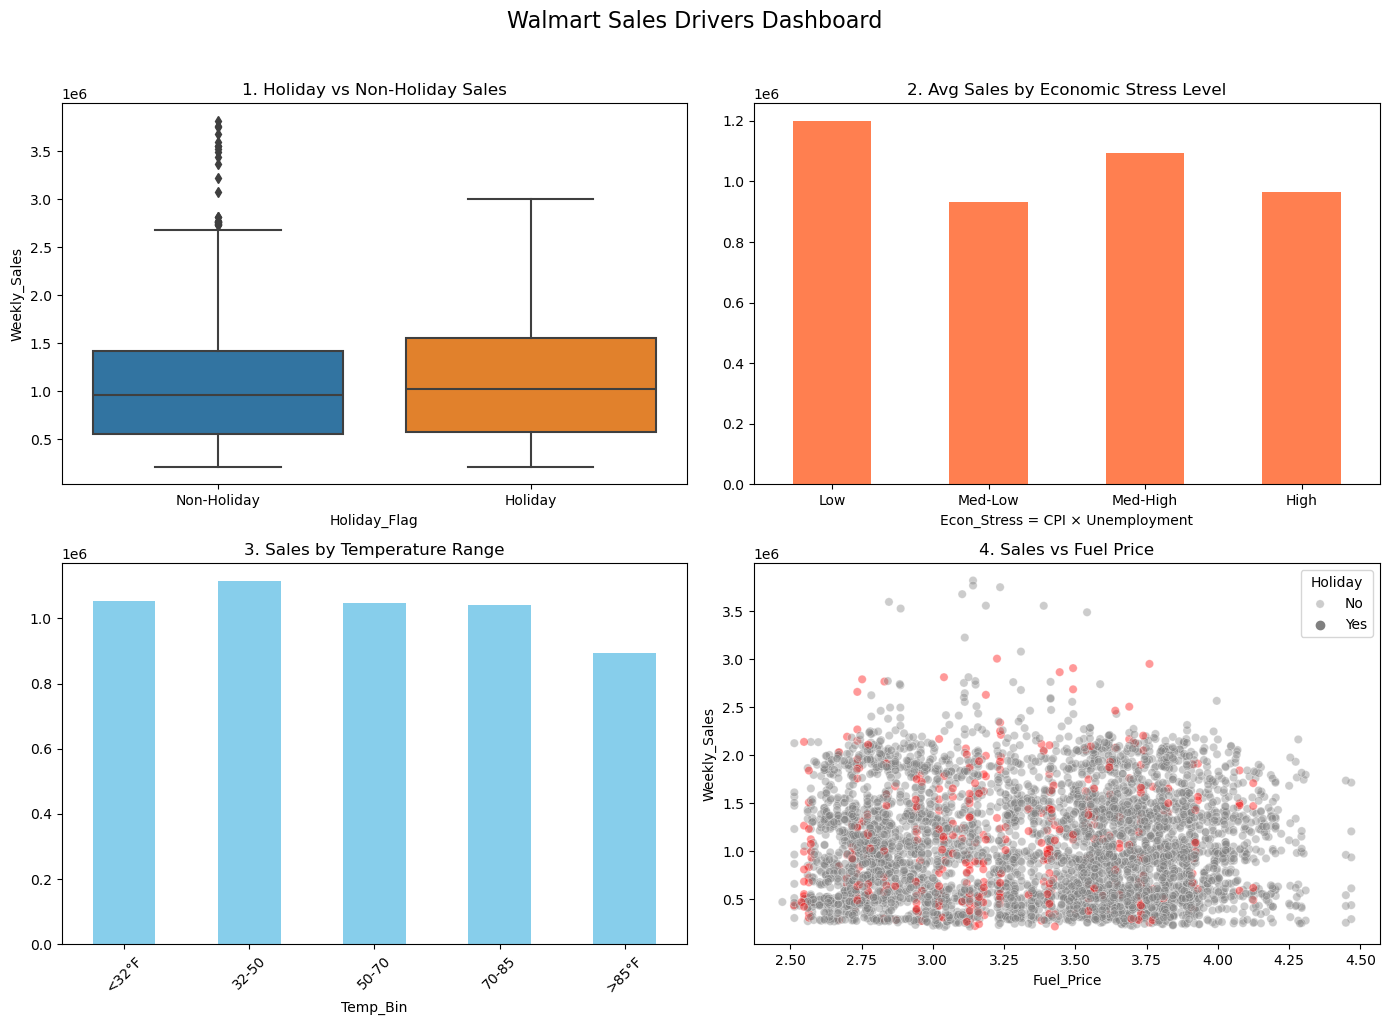

In [180]:
# Subplots with entire analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Walmart Sales Drivers Dashboard', fontsize=16, y=1.02)

# 1. Holiday impact
sns.boxplot(data=df_wal, x='Holiday_Flag', y='Weekly_Sales', ax=axes[0,0])
axes[0,0].set_title('1. Holiday vs Non-Holiday Sales')
axes[0,0].set_xticklabels(['Non-Holiday','Holiday'])

# 2. Economic stress quartiles - your analysis
stress_q = pd.qcut(df_wal['Econ_Stress'], 4, labels=['Low','Med-Low','Med-High','High'])
df_wal.groupby(stress_q)['Weekly_Sales'].mean().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('2. Avg Sales by Economic Stress Level')
axes[0,1].set_xlabel('Econ_Stress = CPI × Unemployment')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Temperature effect 
df_wal['Temp_Bin'] = pd.cut(df_wal['Temperature'], bins=[0,32,50,70,85,110], 
                            labels=['<32°F','32-50','50-70','70-85','>85°F'])
df_wal.groupby('Temp_Bin')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[1,0], color='skyblue')
axes[1,0].set_title('3. Sales by Temperature Range')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Fuel price sensitivity
sns.scatterplot(data=df_wal.sample(5000), x='Fuel_Price', y='Weekly_Sales', 
                hue='Holiday_Flag', alpha=0.4, ax=axes[1,1], palette={0:'gray',1:'red'})
axes[1,1].set_title('4. Sales vs Fuel Price')
axes[1,1].legend(title='Holiday', labels=['No','Yes'])

plt.tight_layout()
plt.show()